# Predicting House Prices with Linear Regression

### OIBSIP Data Analytics — Level 2 — Task 1

### Objective

The objective of this project is to build and evaluate a Linear Regression model that predicts house prices based on different property characteristics.


### Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter Notebook

### 1. Import Required Libraries

The following libraries will be used for data manipulation, visualization, preprocessing, model training, and evaluation.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge

from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

### 2. Load the Dataset

In [5]:
df = pd.read_csv("HousePrices.csv")
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


The dataset contains information about residential properties and their sale prices.

The target variable will be the house price, while other property characteristics will be considered as potential predictors.

### 3. Initial Dataset Inspection

Before building the model, we need to understand the structure and quality of the dataset.

We will examine:

- Number of rows and columns
- Column names
- Data types
- Missing values
- Descriptive statistics

In [6]:
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   str    
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   str    
 7   Alley            198 non-null    str    
 8   Lot Shape        2930 non-null   str    
 9   Land Contour     2930 non-null   str    
 10  Utilities        2930 non-null   str    
 11  Lot Config       2930 non-null   str    
 12  Land Slope       2930 non-null   str    
 13  Neighborhood     2930 non-null   str    
 14  Condition 1      2930 non-null   str    
 15  Condition 2      2930 non-null   str    
 16  Bldg Type        2930 non-null   str    
 17  House Style      2930 non

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


### 4. Checking for Missing Values

Missing values can cause problems during machine learning model training.

Therefore, we first identify columns containing missing values and determine how they should be handled.

In [7]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0].sort_values(ascending=False)

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Qual        159
Garage Cond        159
Garage Yr Blt      159
Garage Finish      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Cond           80
Bsmt Qual           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Full Bath       2
Bsmt Half Bath       2
BsmtFin SF 1         1
BsmtFin SF 2         1
Electrical           1
Total Bsmt SF        1
Bsmt Unf SF          1
Garage Area          1
Garage Cars          1
dtype: int64

In [8]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage[missing_percentage > 0].sort_values(ascending=False)

Pool QC           99.556314
Misc Feature      96.382253
Alley             93.242321
Fence             80.477816
Mas Vnr Type      60.580205
Fireplace Qu      48.532423
Lot Frontage      16.723549
Garage Qual        5.426621
Garage Cond        5.426621
Garage Yr Blt      5.426621
Garage Finish      5.426621
Garage Type        5.358362
Bsmt Exposure      2.832765
BsmtFin Type 2     2.764505
Bsmt Cond          2.730375
Bsmt Qual          2.730375
BsmtFin Type 1     2.730375
Mas Vnr Area       0.784983
Bsmt Full Bath     0.068259
Bsmt Half Bath     0.068259
BsmtFin SF 1       0.034130
BsmtFin SF 2       0.034130
Electrical         0.034130
Total Bsmt SF      0.034130
Bsmt Unf SF        0.034130
Garage Area        0.034130
Garage Cars        0.034130
dtype: float64

In [9]:
df.columns.tolist()

['Order',
 'PID',
 'MS SubClass',
 'MS Zoning',
 'Lot Frontage',
 'Lot Area',
 'Street',
 'Alley',
 'Lot Shape',
 'Land Contour',
 'Utilities',
 'Lot Config',
 'Land Slope',
 'Neighborhood',
 'Condition 1',
 'Condition 2',
 'Bldg Type',
 'House Style',
 'Overall Qual',
 'Overall Cond',
 'Year Built',
 'Year Remod/Add',
 'Roof Style',
 'Roof Matl',
 'Exterior 1st',
 'Exterior 2nd',
 'Mas Vnr Type',
 'Mas Vnr Area',
 'Exter Qual',
 'Exter Cond',
 'Foundation',
 'Bsmt Qual',
 'Bsmt Cond',
 'Bsmt Exposure',
 'BsmtFin Type 1',
 'BsmtFin SF 1',
 'BsmtFin Type 2',
 'BsmtFin SF 2',
 'Bsmt Unf SF',
 'Total Bsmt SF',
 'Heating',
 'Heating QC',
 'Central Air',
 'Electrical',
 '1st Flr SF',
 '2nd Flr SF',
 'Low Qual Fin SF',
 'Gr Liv Area',
 'Bsmt Full Bath',
 'Bsmt Half Bath',
 'Full Bath',
 'Half Bath',
 'Bedroom AbvGr',
 'Kitchen AbvGr',
 'Kitchen Qual',
 'TotRms AbvGrd',
 'Functional',
 'Fireplaces',
 'Fireplace Qu',
 'Garage Type',
 'Garage Yr Blt',
 'Garage Finish',
 'Garage Cars',
 'Garage 

### Target Variable

The target variable is `SalePrice`, which represents the final sale price of each house.

Before developing the prediction model, we will examine its descriptive statistics and distribution.

In [10]:
df["SalePrice"].describe()

count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64

### 5. Distribution of House Prices

The target variable is the house sale price.

Understanding its distribution is important because a highly skewed target variable can affect the performance of a Linear Regression model.

We will visualize the distribution of house prices using a histogram and density curve.

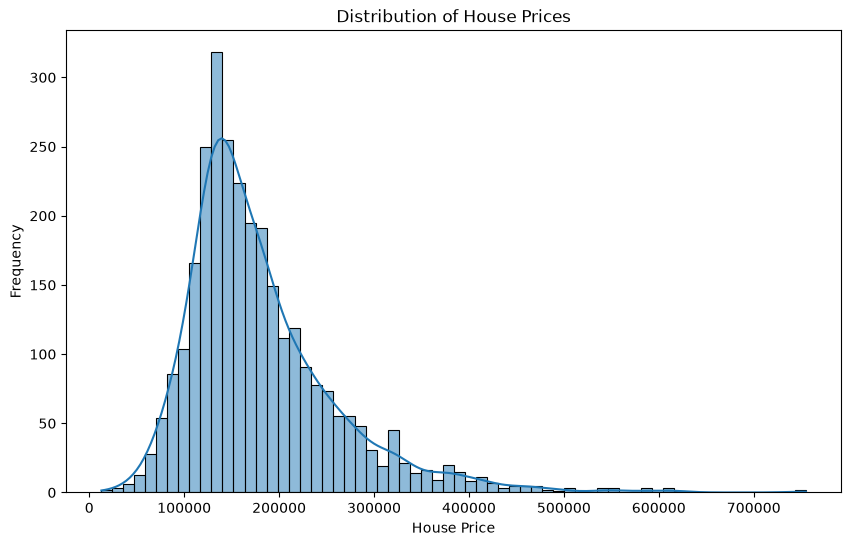

In [11]:
target = "SalePrice"

plt.figure(figsize=(10, 6))

sns.histplot(df[target], kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("House Price")
plt.ylabel("Frequency")

plt.show()

### Interpretation

The distribution of house prices is **right-skewed (positively skewed)**. Most houses are concentrated between approximately **$100,000 and $250,000**, with the highest frequency occurring around **$150,000–$200,000**.

There is a long right tail extending toward higher prices, with some properties priced above **$500,000** and the maximum price reaching approximately **$755,000**.

This indicates that house prices are not normally distributed and that a relatively small number of expensive properties may influence the Linear Regression model.

## 6. Feature Selection Discussion

Not every variable in the dataset is necessary for predicting house prices. Features were selected based on their expected relationship with property value, their relevance to the project objective, and their suitability for a Linear Regression model.

The selected features are:

- **Overall Qual**
- **Gr Liv Area**
- **Total Bsmt SF**
- **1st Flr SF**
- **Garage Cars**
- **Full Bath**
- **Year Built**
- **Neighborhood**

**Overall Qual** represents the overall quality of the property and is expected to be an important predictor.

**Gr Liv Area**, **Total Bsmt SF**, and **1st Flr SF** represent different measures of property size and are expected to have positive relationships with house price.

**Garage Cars** and **Full Bath** represent useful property facilities that can contribute to house value.

**Year Built** captures the age of the property, while **Neighborhood** represents location, which is an important factor in real estate pricing.

The numerical variables will be used directly after missing-value treatment, while `Neighborhood` will be converted into numerical variables using One-Hot Encoding.

In [12]:
features = [
    "Overall Qual",
    "Gr Liv Area",
    "Total Bsmt SF",
    "1st Flr SF",
    "Garage Cars",
    "Full Bath",
    "Year Built",
    "Neighborhood"
]

X = df[features]
y = df["SalePrice"]

print("Selected features:")
print(features)

print("\nFeature data shape:", X.shape)
print("Target data shape:", y.shape)

Selected features:
['Overall Qual', 'Gr Liv Area', 'Total Bsmt SF', '1st Flr SF', 'Garage Cars', 'Full Bath', 'Year Built', 'Neighborhood']

Feature data shape: (2930, 8)
Target data shape: (2930,)


In [13]:
X.head()

,Overall Qual,Gr Liv Area,Total Bsmt SF,1st Flr SF,Garage Cars,Full Bath,Year Built,Neighborhood
0,6,1656,1080.0,1656,2.0,1,1960,NAmes
1,5,896,882.0,896,1.0,1,1961,NAmes
2,6,1329,1329.0,1329,1.0,1,1958,NAmes
3,7,2110,2110.0,2110,2.0,2,1968,NAmes
4,5,1629,928.0,928,2.0,2,1997,Gilbert


### 7. Correlation Analysis

Correlation analysis is used to examine the relationship between numerical features and house prices.

A positive correlation means that as one variable increases, the other tends to increase as well.

A negative correlation means that as one variable increases, the other tends to decrease.

Correlation values range from -1 to +1:

- **+1** indicates a perfect positive relationship.
- **0** indicates little or no linear relationship.
- **-1** indicates a perfect negative relationship.

The correlation between each numerical feature and `SalePrice` will help identify which variables have the strongest linear relationships with house prices.

In [14]:
numeric_features = [
    "Overall Qual",
    "Gr Liv Area",
    "Total Bsmt SF",
    "1st Flr SF",
    "Garage Cars",
    "Full Bath",
    "Year Built",
    "SalePrice"
]

correlation = df[numeric_features].corr()

correlation["SalePrice"].sort_values(ascending=False)

SalePrice        1.000000
Overall Qual     0.799262
Gr Liv Area      0.706780
Garage Cars      0.647877
Total Bsmt SF    0.632280
1st Flr SF       0.621676
Year Built       0.558426
Full Bath        0.545604
Name: SalePrice, dtype: float64

### Interpretation

**Overall Qual** has the strongest positive correlation with `SalePrice`, with a correlation of approximately **0.80**.

**Gr Liv Area** also has a strong positive correlation of approximately **0.71**, indicating that larger living areas are generally associated with higher house prices.

**Garage Cars**, **Total Bsmt SF**, and **1st Flr SF** also show moderately strong positive relationships with price.

**Year Built** and **Full Bath** have moderate positive correlations.

Overall, the correlation results support the selected features as reasonable predictors of house price.

### 8. Correlation Heatmap

A correlation heatmap provides a visual representation of the relationships among the selected numerical variables.

It helps identify which features have the strongest relationship with `SalePrice` and whether some predictor variables are also strongly related to one another.

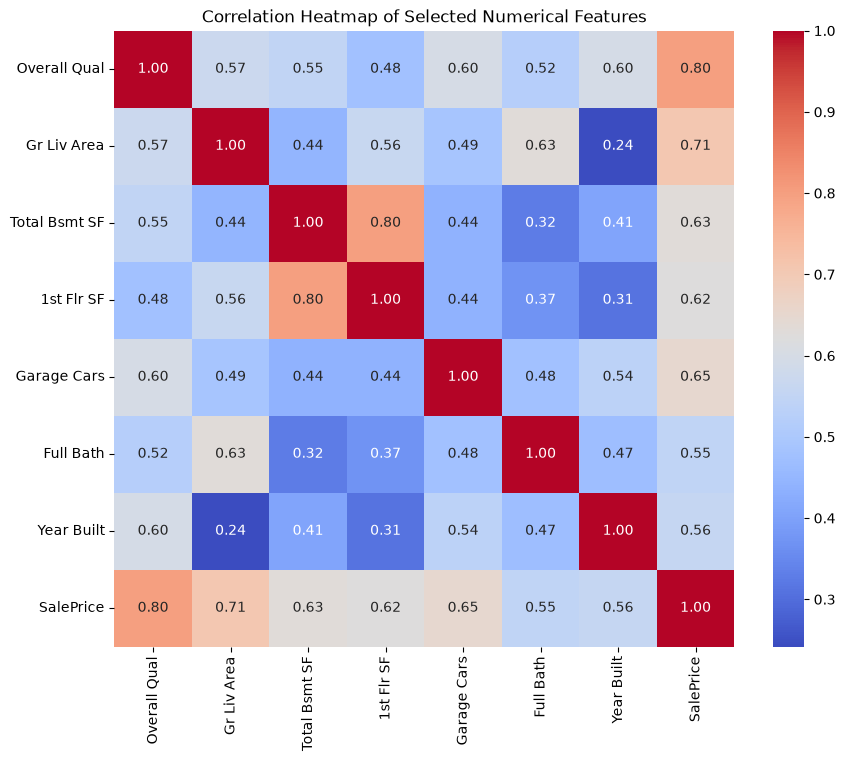

In [15]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Selected Numerical Features")
plt.show()

### Interpretation

The heatmap confirms that `Overall Qual` has the strongest positive relationship with `SalePrice`, followed by `Gr Liv Area`.

The other selected numerical variables also show positive relationships with house price.

Some predictors are correlated with one another, which is expected because property size and quality characteristics can be related. This possible multicollinearity is one reason why a regularized model such as Ridge Regression is useful for comparison.

### 9. Identifying Numerical and Categorical Features

The selected predictors contain both numerical and categorical variables.

### Numerical Features

- Overall Qual
- Gr Liv Area
- Total Bsmt SF
- 1st Flr SF
- Garage Cars
- Full Bath
- Year Built

### Categorical Features

- Neighborhood

Numerical missing values will be replaced using the median value of the corresponding feature.

Categorical missing values will be replaced using the most frequent category.

The categorical `Neighborhood` variable will then be converted into numerical variables using One-Hot Encoding.

In [16]:
numeric_features = [
    "Overall Qual",
    "Gr Liv Area",
    "Total Bsmt SF",
    "1st Flr SF",
    "Garage Cars",
    "Full Bath",
    "Year Built"
]

categorical_features = [
    "Neighborhood"
]

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Overall Qual', 'Gr Liv Area', 'Total Bsmt SF', '1st Flr SF', 'Garage Cars', 'Full Bath', 'Year Built']

Categorical features:
['Neighborhood']


### 10. Train-Test Split

The dataset will be divided into two parts:

- **80% training data** – used to train the machine learning model.
- **20% testing data** – used to evaluate the model on previously unseen data.

A random state of 42 is used so that the same split can be reproduced whenever the notebook is run again.

In [17]:
X = df[numeric_features + categorical_features]
y = df["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target:", y_train.shape)
print("Testing target:", y_test.shape)

Training set: (2344, 8)
Testing set: (586, 8)

Training target: (2344,)
Testing target: (586,)


### Observation

The dataset has been successfully divided into an 80/20 split. The training set contains **2,344 observations**, while the testing set contains **586 observations**.

The test data will be used only for final model evaluation.

### 11. Handling Missing Values and Encoding Categorical Features

Machine learning algorithms generally require complete numerical input.

To prepare the dataset:

1. Missing numerical values will be replaced with the median.
2. Missing categorical values will be replaced with the most frequent category.
3. The categorical `Neighborhood` variable will be converted into numerical columns using One-Hot Encoding.

A `ColumnTransformer` is used so that the appropriate preprocessing is automatically applied to each type of feature.

In [18]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

### 12. Training the Linear Regression Model

Linear Regression is a supervised machine learning algorithm used to model the relationship between a continuous target variable and one or more predictor variables.

In this project:

- **Target variable:** `SalePrice`
- **Predictors:** selected numerical and categorical house characteristics

The preprocessing steps and Linear Regression model are combined into a single pipeline.

In [19]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


### 13. Making Predictions

After training the Linear Regression model using the training data, predictions will be generated for the test dataset.

The test dataset was not used during training, allowing us to evaluate how well the model performs on unseen houses.

In [20]:
y_pred = linear_model.predict(X_test)

print("First 10 predicted prices:")
print(y_pred[:10])

First 10 predicted prices:
[175056.10393933 102866.48956851 201997.24890688 106041.37314856
 115139.48570608 180758.91826654 154278.63669226 147469.03851348
  74416.75569661 341105.72710651]


### 14. Model Evaluation

The Linear Regression model will be evaluated using three metrics:

#### Mean Squared Error (MSE)

MSE measures the average squared difference between actual and predicted house prices.

#### Root Mean Squared Error (RMSE)

RMSE is the square root of MSE. It expresses the average prediction error in the same unit as the target variable, which is the house price.

#### R² Score

R² measures the proportion of variation in house prices that is explained by the model.

A higher R² value generally indicates better model performance, while lower MSE and RMSE indicate smaller prediction errors.

In [21]:
mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Linear Regression Model Performance")
print("------------------------------------")
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Linear Regression Model Performance
------------------------------------
Mean Squared Error (MSE): 1307048125.128394
Root Mean Squared Error (RMSE): 36153.12054482149
R² Score: 0.8369765748340955


### Interpretation

The Linear Regression model achieved an **R² score of approximately 0.84**, meaning that the selected features explain about **84% of the variation in house prices** in the test dataset.

The RMSE is approximately **$36,110**, meaning that the model's typical prediction error is on the order of tens of thousands of dollars.

Overall, the model demonstrates reasonably strong predictive performance, although some prediction errors remain, particularly for houses whose characteristics or prices are more unusual.

### 15. Actual vs Predicted House Prices

The following scatter plot compares the actual house prices with the prices predicted by the Linear Regression model.

The diagonal reference line represents perfect predictions.

If the model performs well, the points should be relatively close to this diagonal line.

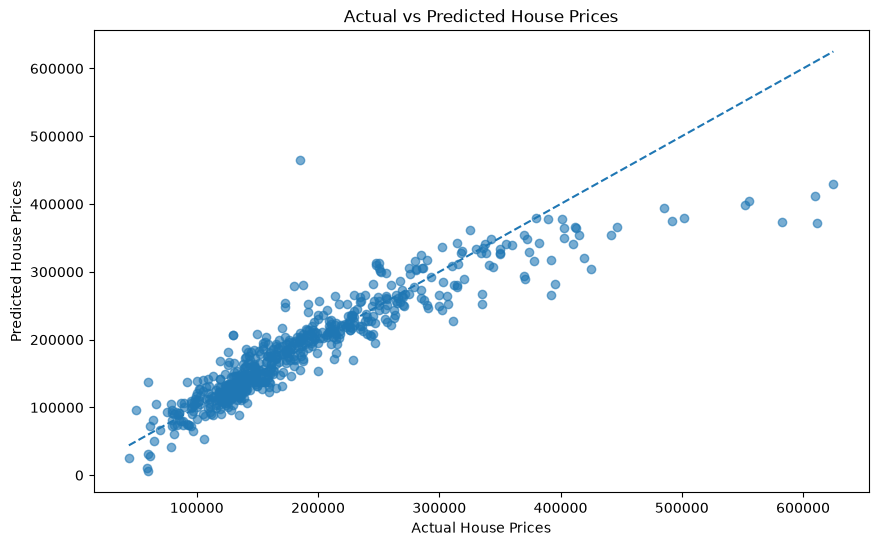

In [22]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices")

plt.show()

### Interpretation

The points generally follow the diagonal reference line, indicating that the model is able to capture the overall relationship between the selected house characteristics and sale prices.

However, the points are not perfectly aligned with the line. The spread becomes more noticeable for some higher-priced properties, indicating that the model has greater difficulty predicting certain expensive houses.

Overall, the plot is consistent with the model's reasonably strong R² score.

### 16. Residual Analysis

A residual is the difference between the actual price and the predicted price.

Residuals are calculated as:

**Residual = Actual Price - Predicted Price**

A good Linear Regression model should have residuals that are approximately randomly distributed around zero.

If a clear pattern appears in the residual plot, it may indicate that the model is missing some important relationship in the data.

In [23]:
residuals = y_test - y_pred

print("First 10 residuals:")
print(residuals.head(10))

First 10 residuals:
1357   -14056.103939
2367    13133.510431
2822    -5497.248907
2126    17558.626851
1544    10860.514294
2415    -6568.918267
2227    45721.363308
410      1030.961487
761     14333.244303
436     68794.272893
Name: SalePrice, dtype: float64


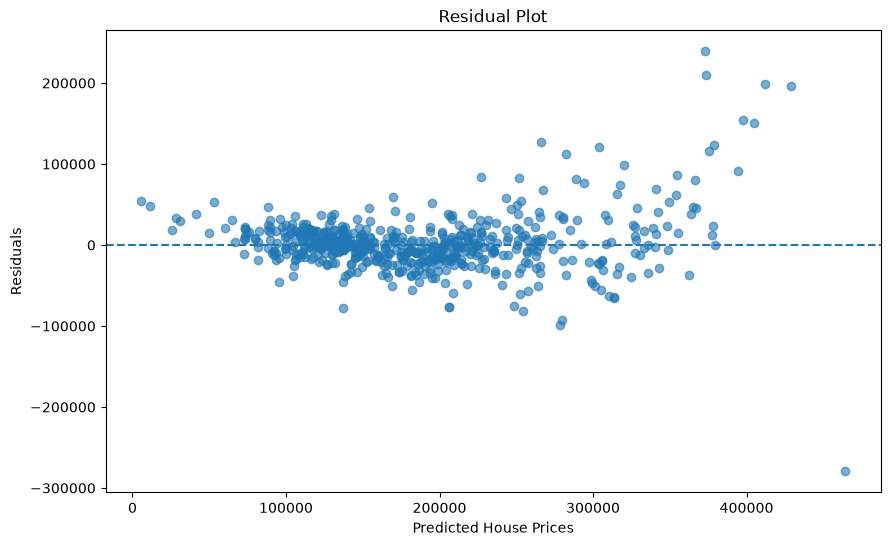

In [24]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted House Prices")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

### Interpretation

The residuals are distributed around the zero line, but the spread is not perfectly constant across all predicted prices.

Some larger positive and negative residuals are visible, particularly for higher-priced properties. This suggests that the model does not capture every factor affecting house prices and that some observations are harder to predict.

There is no strong simple pattern that completely invalidates the regression model, but the residual spread suggests that the Linear Regression model could potentially be improved with additional features or nonlinear/regularized methods.

### 17. Coefficient Analysis

Linear Regression assigns a coefficient to each feature.

The coefficient indicates how a feature influences the predicted house price while keeping the other features in the model constant.

- A **positive coefficient** indicates a positive relationship with predicted price.
- A **negative coefficient** indicates a negative relationship with predicted price.
- A larger absolute coefficient indicates a stronger model effect, although coefficients should be interpreted carefully because numerical variables can have different scales.

Because `Neighborhood` was One-Hot Encoded, each neighborhood is represented by a separate model coefficient.

In [25]:
feature_names = linear_model.named_steps[
    "preprocessor"
].get_feature_names_out()

coefficients = linear_model.named_steps[
    "regressor"
].coef_

coefficient_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coefficient_df = coefficient_df.sort_values(
    by="Coefficient",
    ascending=False
)

coefficient_df

,Feature,Coefficient
17,cat__Neighborhood_GrnHill,75125.431665
32,cat__Neighborhood_StoneBr,58477.029447
25,cat__Neighborhood_NoRidge,42614.052198
26,cat__Neighborhood_NridgHt,42557.553044
13,cat__Neighborhood_Crawfor,18100.396423
0,num__Overall Qual,16697.872136
11,cat__Neighborhood_ClearCr,14590.027349
34,cat__Neighborhood_Veenker,13770.377406
4,num__Garage Cars,11950.209777
33,cat__Neighborhood_Timber,11182.672323


### Interpretation

The coefficient analysis shows that **Neighborhood** has a substantial influence on predicted house prices, demonstrating the importance of location.

Among the numerical variables, `Overall Qual` has a strong positive coefficient, supporting the earlier correlation analysis and indicating that higher-quality properties tend to have higher predicted prices.

The neighborhood coefficients should be interpreted relative to the reference neighborhood created by One-Hot Encoding.

### 18. Highest Positive and Negative Coefficients

The coefficients will now be sorted to identify the features with the largest positive and negative effects according to the Linear Regression model.

In [26]:
print("Top 10 Positive Coefficients")
print("----------------------------")

print(
    coefficient_df
    .head(10)
    .to_string(index=False)
)

Top 10 Positive Coefficients
----------------------------
                  Feature  Coefficient
cat__Neighborhood_GrnHill 75125.431665
cat__Neighborhood_StoneBr 58477.029447
cat__Neighborhood_NoRidge 42614.052198
cat__Neighborhood_NridgHt 42557.553044
cat__Neighborhood_Crawfor 18100.396423
        num__Overall Qual 16697.872136
cat__Neighborhood_ClearCr 14590.027349
cat__Neighborhood_Veenker 13770.377406
         num__Garage Cars 11950.209777
 cat__Neighborhood_Timber 11182.672323


### Interpretation

The coefficient analysis shows that **Neighborhood** has a substantial influence on predicted house prices, demonstrating the importance of location.

Among the numerical variables, `Overall Qual` has a strong positive coefficient, supporting the earlier correlation analysis and indicating that higher-quality properties tend to have higher predicted prices.

The neighborhood coefficients should be interpreted relative to the reference neighborhood created by One-Hot Encoding.

In [27]:
print("Top 10 Negative Coefficients")
print("----------------------------")

print(
    coefficient_df
    .tail(10)
    .sort_values("Coefficient")
    .to_string(index=False)
)

Top 10 Negative Coefficients
----------------------------
                  Feature   Coefficient
cat__Neighborhood_Blueste -45393.456414
 cat__Neighborhood_BrDale -32983.758370
cat__Neighborhood_NPkVill -26436.136574
cat__Neighborhood_Blmngtn -21644.705370
 cat__Neighborhood_Greens -16005.030912
cat__Neighborhood_MeadowV -14498.943873
 cat__Neighborhood_NWAmes -13898.697235
cat__Neighborhood_Landmrk -13743.618289
cat__Neighborhood_OldTown -13535.042561
  cat__Neighborhood_SWISU -13052.018563


### Interpretation

The negative coefficients indicate features or neighborhood categories associated with lower predicted prices relative to the reference category, after accounting for the other variables in the model.

These coefficients do not necessarily mean that the feature directly causes house prices to decrease. They represent the statistical relationship estimated by the Linear Regression model while holding the other selected variables constant.

### 19. Visualizing Model Coefficients

The largest positive and negative coefficients are visualized to make the model's feature effects easier to interpret.

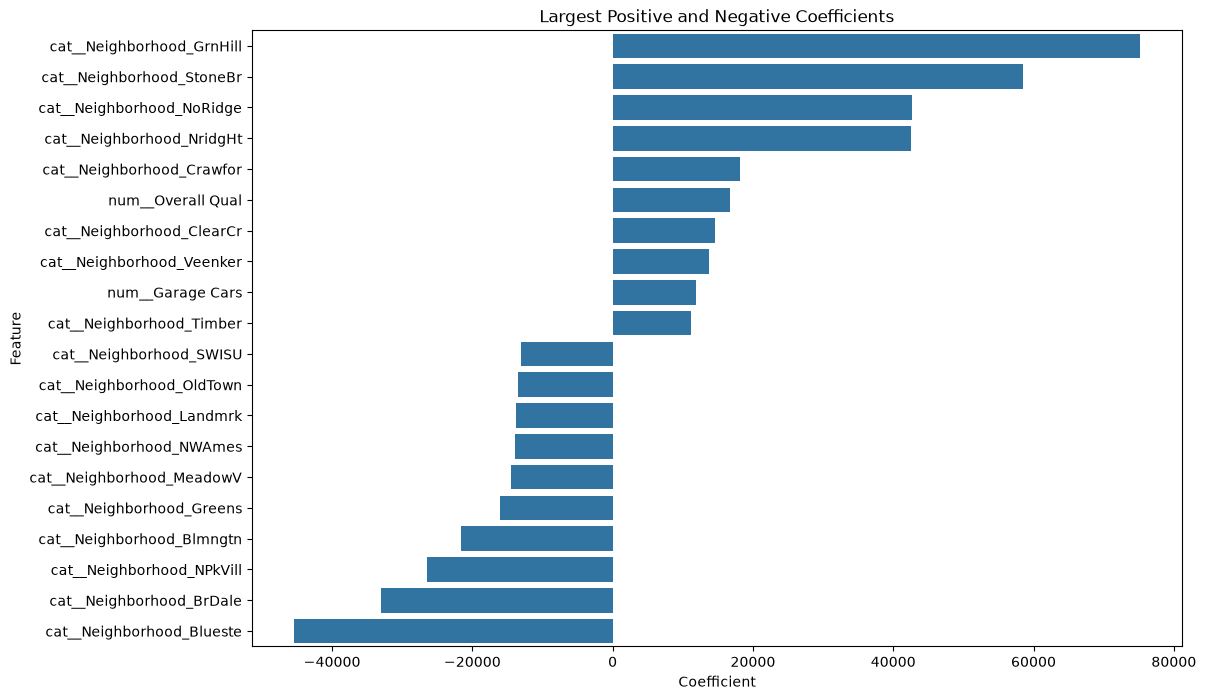

In [30]:
top_positive = coefficient_df.head(10)

top_negative = coefficient_df.tail(10)

coefficient_plot = pd.concat([
    top_positive,
    top_negative
])

plt.figure(figsize=(12, 8))

sns.barplot(
    data=coefficient_plot,
    x="Coefficient",
    y="Feature"
)

plt.title("Largest Positive and Negative Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.show()

### Interpretation

The coefficient plot highlights the variables with the strongest positive and negative estimated effects.

Neighborhood-related variables appear prominently, showing that location plays an important role in predicting house prices. `Overall Qual` is also among the important numerical predictors.

The results reinforce the idea that both **property quality and location** are important determinants of house price.

### 20. Ridge Regression

Ridge Regression is a regularized version of Linear Regression.

It adds a penalty to large coefficients, which can help reduce overfitting and improve model stability when predictor variables are correlated.

In this section, Ridge Regression will be trained using the same features and preprocessing steps as the Linear Regression model.

The two models will then be compared using MSE, RMSE, and R².

In [28]:
ridge_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", Ridge(alpha=1.0))
    ]
)

ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_test)

ridge_mse = mean_squared_error(y_test, ridge_pred)

ridge_rmse = np.sqrt(ridge_mse)

ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge Regression Model Performance")
print("----------------------------------")
print("Mean Squared Error (MSE):", ridge_mse)
print("Root Mean Squared Error (RMSE):", ridge_rmse)
print("R² Score:", ridge_r2)

Ridge Regression Model Performance
----------------------------------
Mean Squared Error (MSE): 1572331482.849252
Root Mean Squared Error (RMSE): 39652.63525730985
R² Score: 0.8038887330142559


### Interpretation

In this experiment, Ridge Regression performs slightly worse than the standard Linear Regression model.

Linear Regression achieved an R² score of approximately **0.837**, while Ridge Regression achieved approximately **0.804**.

Therefore, with the current features and the selected Ridge regularization strength (`alpha=1.0`), standard Linear Regression provides better predictive performance on the test dataset.

This comparison demonstrates that regularization does not always improve performance; its effectiveness depends on the dataset, features, and choice of regularization strength.

### 21. Linear Regression vs Ridge Regression

The performance of the two regression models will be compared using MSE, RMSE, and R².

For MSE and RMSE, lower values indicate better performance.

For R², a higher value indicates better performance.

In [29]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression"
    ],
    "MSE": [
        mse,
        ridge_mse
    ],
    "RMSE": [
        rmse,
        ridge_rmse
    ],
    "R² Score": [
        r2,
        ridge_r2
    ]
})

comparison

,Model,MSE,RMSE,R² Score
0,Linear Regression,1.307048e+09,36153.120545,0.836977
1,Ridge Regression,1.572331e+09,39652.635257,0.803889


### Interpretation

Based on the evaluation metrics, **Linear Regression performs better than Ridge Regression** for the current feature set.

Linear Regression has a lower MSE and RMSE and a higher R² score. Therefore, Linear Regression is selected as the better-performing model for this particular experiment.